# K-Means Clustering


**Key idea:** K-Means approximates your data with **k** prototype points (centroids). Each sample belongs to the nearest centroid.

---

- Fit KMeans, inspect `labels_`, `cluster_centers_`, `inertia_`
- Visualize clusters and decision regions
- Choose `k` (elbow + silhouette)
- See where K-Means fails (non-spherical / non-convex clusters)
- Compare with Agglomerative clustering and DBSCAN
- Practical tips: scaling, initialization, stability, reproducibility


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Make plots a bit larger 
plt.rcParams["figure.figsize"] = (7, 5)


In [31]:
def scatter_2d(X, labels=None, centers=None, title=None, alpha=0.8, s=20):
    """A minimal 2D scatter helper (no seaborn)."""
    plt.figure()
    if labels is None:
        plt.scatter(X[:, 0], X[:, 1], s=s, alpha=alpha)
    else:
        # matplotlib maps integer labels to colors automatically
        plt.scatter(X[:, 0], X[:, 1], c=labels, s=s, alpha=alpha)
    if centers is not None:
        plt.scatter(centers[:, 0], centers[:, 1], s=200, marker="X")
    if title:
        plt.title(title)
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.show()


def plot_kmeans_boundaries(model, X, padding=0.5, step=0.02, title=None):
    """Plot the Voronoi-like decision regions induced by K-Means (2D only)."""
    x_min, x_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    y_min, y_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    grid = np.c_[xx.ravel(), yy.ravel()]
    pred = model.predict(grid).reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, pred, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=model.labels_, s=20, alpha=0.8)
    plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
                s=200, marker="X")
    if title:
        plt.title(title)
    plt.xlabel("feature 1")
    plt.ylabel("feature 2")
    plt.show()


## 1. Start with an easy case: well-separated blobs

We generate synthetic data with clear, roughly spherical clusters.

**Model objective (informal):**
K-Means chooses centroids $\mu_1,\dots,\mu_k$ to minimize the within-cluster sum of squares:

\begin{align*}
\text{inertia} = \sum_{i=1}^n \min_{j\in\{1..k\}} \|x_i-\mu_j\|^2
\end{align*}

In scikit-learn, this value is available as `kmeans.inertia_` after fitting.


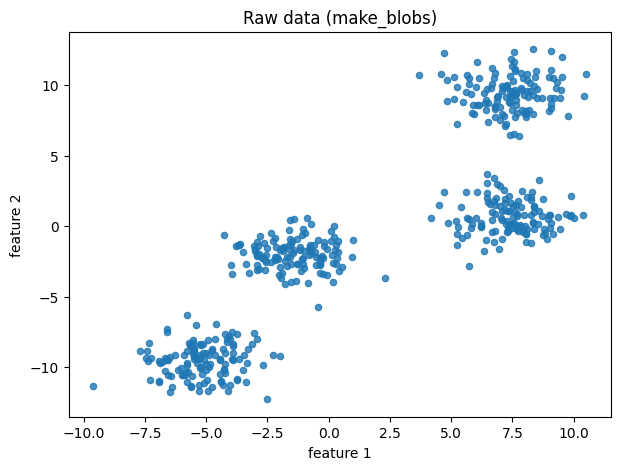

labels_ shape: (500,)
cluster_centers_ shape: (4, 2)
inertia_: 1483.49


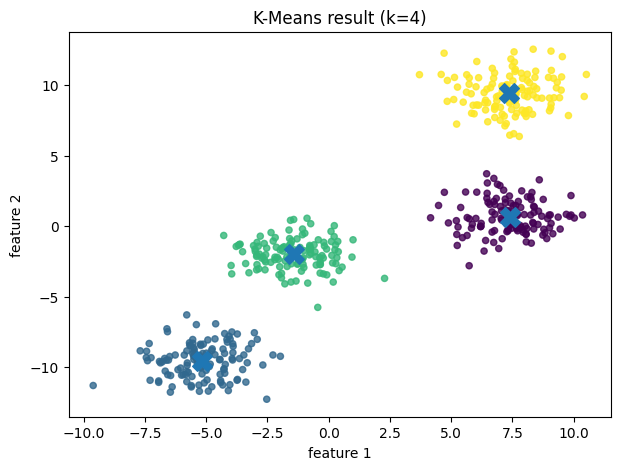

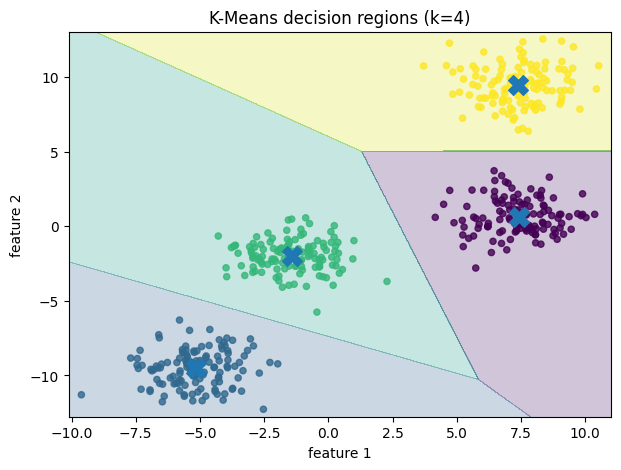

In [32]:
# Generate an easy clustering dataset
X, y_true = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.2,
    random_state=8
)

scatter_2d(X, title="Raw data (make_blobs)")

# Fit KMeans
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto")
kmeans.fit(X)

print("labels_ shape:", kmeans.labels_.shape)
print("cluster_centers_ shape:", kmeans.cluster_centers_.shape)
print("inertia_:", round(kmeans.inertia_, 2))

scatter_2d(X, labels=kmeans.labels_, centers=kmeans.cluster_centers_,
          title="K-Means result (k=4)")

plot_kmeans_boundaries(kmeans, X, title="K-Means decision regions (k=4)")


### Predicting cluster for new points

K-Means can assign *new* points to the nearest learned centroid.

- `predict(new_X)` returns cluster indices.
- Note: cluster indices are arbitrary (label switching is normal).

new points:
 [[-2 -6]
 [ 0  0]
 [ 7 -1]]
predicted clusters: [2 2 0]


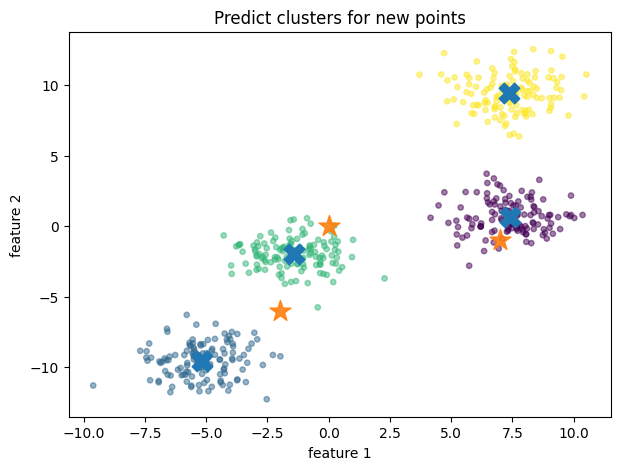

In [33]:
new_points = np.array([
    [-2, -6],
    [ 0,  0],
    [ 7, -1]
])

pred = kmeans.predict(new_points)
print("new points:\n", new_points)
print("predicted clusters:", pred)

# Visualize with the learned centers
plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=15, alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=220, marker="X")
plt.scatter(new_points[:, 0], new_points[:, 1], s=250, marker="*", alpha=0.9)
plt.title("Predict clusters for new points")
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.show()


## 2 How do we pick `k`?

There is no single perfect rule, but two practical diagnostics are common:

### (A) Elbow method (inertia)
Compute inertia for multiple k, look for a *knee* where improvements slow down.

### (B) Silhouette score
Measures how well-separated clusters are (higher is better).
It is defined using pairwise distances, so it can be slower on very large data.


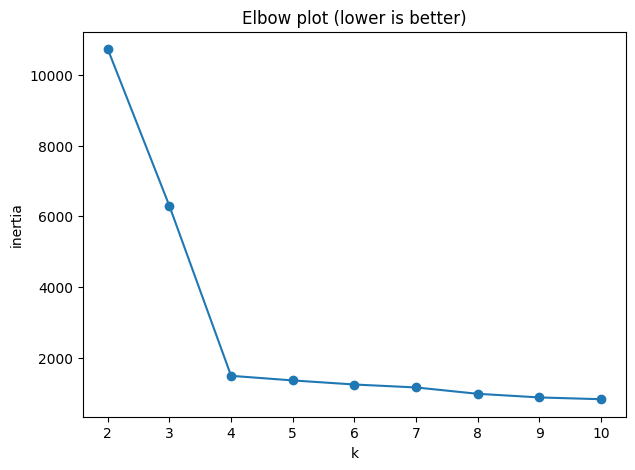

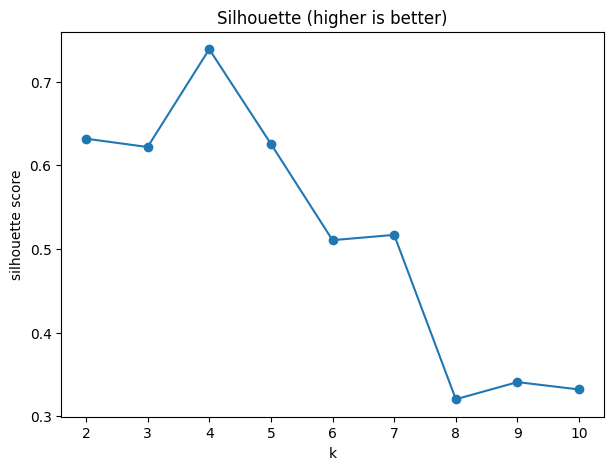

    k    inertia  silhouette
0   2  10729.132       0.632
1   3   6288.887       0.622
2   4   1483.486       0.739
3   5   1353.207       0.626
4   6   1237.616       0.510
5   7   1154.009       0.517
6   8    974.514       0.320
7   9    871.555       0.341
8  10    820.999       0.332


In [35]:
def k_diagnostics(X, k_list, random_state=0):
    inertias = []
    silhouettes = []
    for k in k_list:
        model = KMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = model.fit_predict(X)
        inertias.append(model.inertia_)
        # silhouette requires at least 2 clusters and not all points in one cluster
        silhouettes.append(silhouette_score(X, labels))
    return np.array(inertias), np.array(silhouettes)

k_list = np.arange(2, 11)
inertias, sils = k_diagnostics(X, k_list)

plt.figure()
plt.plot(k_list, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("Elbow plot (lower is better)")
plt.show()

plt.figure()
plt.plot(k_list, sils, marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")
plt.title("Silhouette (higher is better)")
plt.show()

print(pd.DataFrame({"k": k_list, "inertia": inertias, "silhouette": sils}).round(3))


## 3 When K-Means struggles

K-Means tends to work best when clusters are:

- roughly spherical / convex in feature space
- similar size (variance)
- separable by Euclidean distance

Let's create two classic “failure” examples:

1) **Stretched (anisotropic) blobs**
2) **Two moons** (non-convex structure)

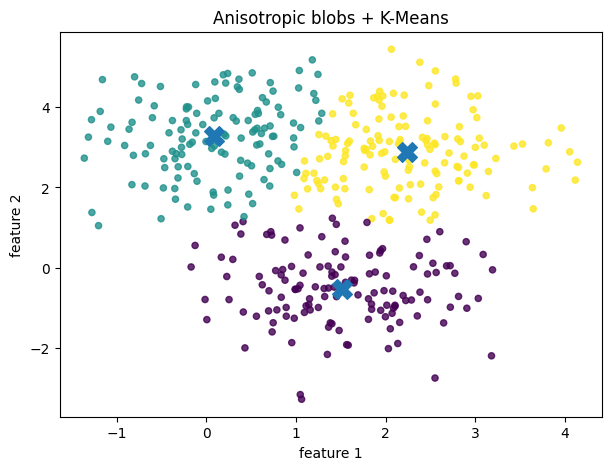

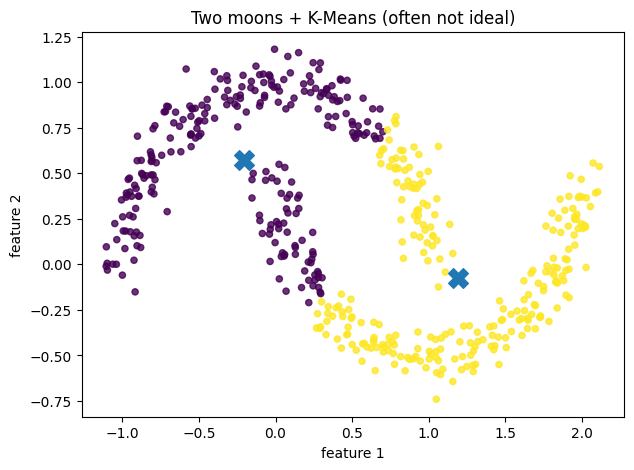

In [36]:
# (1) Stretched (anisotropic) blobs
X0, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.0, random_state=0)
A = np.array([[0.6, -0.6], [0.4, 0.8]])  # linear transform
X_aniso = X0 @ A

kmeans_aniso = KMeans(n_clusters=3, random_state=0, n_init="auto").fit(X_aniso)
scatter_2d(X_aniso, labels=kmeans_aniso.labels_, centers=kmeans_aniso.cluster_centers_,
          title="Anisotropic blobs + K-Means")

# (2) Two moons
X_moons, y_moons = make_moons(n_samples=500, noise=0.08, random_state=0)
kmeans_moons = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X_moons)
scatter_2d(X_moons, labels=kmeans_moons.labels_, centers=kmeans_moons.cluster_centers_,
          title="Two moons + K-Means (often not ideal)")


## 4 Compare with other clustering methods

### Agglomerative clustering (hierarchical, bottom-up)
Often handles some shapes better than K-Means, but still struggles with non-convex patterns.

### DBSCAN (density-based)
Can capture non-convex clusters and isolate noise points, but is sensitive to `eps` and `min_samples`.

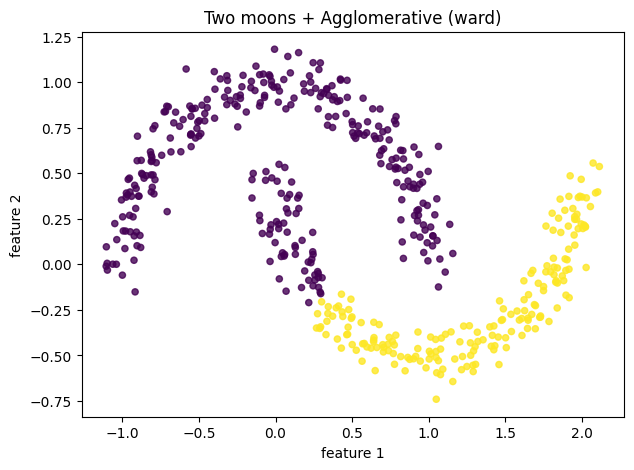

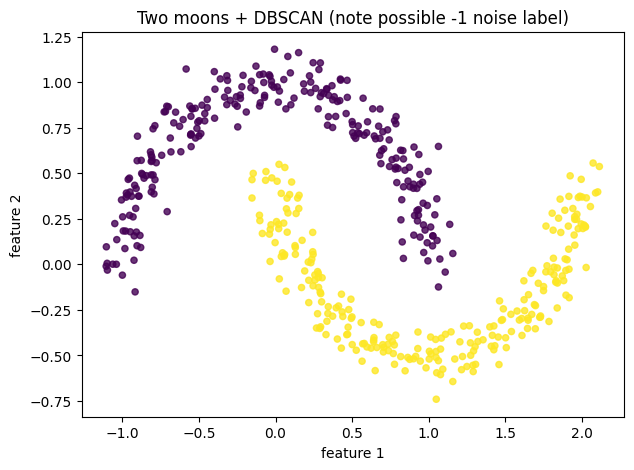

Unique DBSCAN labels: [0 1]


In [37]:
# Agglomerative on moons
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
labels_agg = agg.fit_predict(X_moons)
scatter_2d(X_moons, labels=labels_agg, title="Two moons + Agglomerative (ward)")

# DBSCAN on moons
db = DBSCAN(eps=0.2, min_samples=10)
labels_db = db.fit_predict(X_moons)
# DBSCAN can output -1 for noise
scatter_2d(X_moons, labels=labels_db, title="Two moons + DBSCAN (note possible -1 noise label)")
print("Unique DBSCAN labels:", np.unique(labels_db))


## 5 Evaluation (when you *do* have ground truth labels)

Clustering is usually **unsupervised**, but in synthetic demos we know the “true” labels.

A common pitfall:
- cluster indices are arbitrary (label switching),
- so plain accuracy is misleading.

Instead, use an index that is invariant to label permutations, e.g. **Adjusted Rand Index (ARI)**.

In [38]:
# On the original blobs, compare clustering to y_true with ARI
ari = adjusted_rand_score(y_true, kmeans.labels_)
print("Adjusted Rand Index (ARI):", round(ari, 4))


Adjusted Rand Index (ARI): 1.0


## 6 Practical tips (for “real” data)

### Scaling
K-Means uses Euclidean distances, so feature scales matter.
If variables have different units/ranges, standardize or normalize.

### Stability
Try multiple random seeds; small changes can swap assignments when clusters overlap.

### Pipeline is a good tool
Use `Pipeline([('scaler', ...), ('kmeans', ...)])` to avoid forgetting preprocessing.


In [40]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=0, n_init="auto"))
])

pipe.fit(X)  # X here is already 2D blobs, scaling is harmless
labels_pipe = pipe["kmeans"].labels_
centers_pipe = pipe["kmeans"].cluster_centers_  # note: centers are in *scaled* space inside pipeline

print("Pipeline fitted. labels_ example:", labels_pipe[:10])

# If we need centers in original units, we would inverse-transform them via the scaler:
centers_original = pipe["scaler"].inverse_transform(centers_pipe)
print("Centers (original scale) shape:", centers_original.shape)


Pipeline fitted. labels_ example: [0 1 1 0 3 2 1 1 1 3]
Centers (original scale) shape: (4, 2)
